# 02. Признаки answer + description

Второй эксперимент: извлекаем статистические признаки из двух текстовых полей, `answer` и `description`, и сравниваем качество с baseline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Загрузка данных

In [2]:
DATA_PATH = Path("../data.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,id,answer,description,date_posted,img_url,started,solved,users_with_hints,total_hints,solve_rate,hint_usage,avg_hints,difficulty
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,2025-06-01,/daily-rebuses/1_v1.jpg,454,219,110,179,0.4824,0.2423,0.3943,0.4303
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,2025-06-02,/daily-rebuses/2.jpg,339,162,65,90,0.4779,0.1917,0.2655,0.4010
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,2025-06-03,/daily-rebuses/3_v1.jpg,276,134,38,56,0.4855,0.1377,0.2029,0.3736
3,4,подоконник,Под О Конь и К,2025-06-04,/daily-rebuses/4.jpg,255,183,19,28,0.7176,0.0745,0.1098,0.2045
4,5,редактор,Красный актер = Red Actor,2025-06-05,/daily-rebuses/5_v1.jpg,311,200,96,158,0.6431,0.3087,0.5080,0.3675


## Извлечение текстовых признаков

In [3]:
VOWELS = set("аеёиоуыэюя")
RARE_LETTERS = set("фщъёцэ")

def extract_text_stats(text, prefix=""):
    if pd.isna(text):
        text = ""
    
    # Для ответа берем только первый вариант до |
    text = str(text).lower().strip()
    if "|" in text:
        text = text.split("|")[0].strip()
    
    compact = text.replace(" ", "")
    words = [word for word in text.split() if word]
    
    letters = [char for char in compact if char.isalpha()]
    cyrillic_letters = [char for char in letters if "а" <= char <= "я" or char == "ё"]
    latin_letters = [char for char in letters if "a" <= char <= "z"]
    
    len_chars = len(compact)
    vowel_count = sum(char in VOWELS for char in compact)
    consonant_count = sum(char.isalpha() and char not in VOWELS for char in compact)
    rare_count = sum(char in RARE_LETTERS for char in compact)
    unique_chars = len(set(compact))
    
    stats = {
        f"{prefix}len_chars": len_chars,
        f"{prefix}len_words": len(words),
        f"{prefix}avg_word_len": len_chars / len(words) if words else 0.0,
        f"{prefix}vowel_count": vowel_count,
        f"{prefix}consonant_count": consonant_count,
        f"{prefix}rare_count": rare_count,
        f"{prefix}unique_chars": unique_chars,
        f"{prefix}vowel_ratio": vowel_count / len_chars if len_chars else 0.0,
        f"{prefix}rare_ratio": rare_count / len_chars if len_chars else 0.0,
        f"{prefix}unique_ratio": unique_chars / len_chars if len_chars else 0.0,
        f"{prefix}cyrillic_ratio": len(cyrillic_letters) / len(letters) if letters else 0.0,
        f"{prefix}latin_ratio": len(latin_letters) / len(letters) if letters else 0.0,
        f"{prefix}has_dash": int("-" in text),
        f"{prefix}has_digits": int(any(char.isdigit() for char in text)),
    }
    return pd.Series(stats)

answer_features = df["answer"].apply(lambda x: extract_text_stats(x, prefix="ans_"))
desc_features = df["description"].apply(lambda x: extract_text_stats(x, prefix="desc_"))

X = pd.concat([answer_features, desc_features], axis=1)
y = df["difficulty"]

X.head()

,ans_len_chars,ans_len_words,ans_avg_word_len,ans_vowel_count,ans_consonant_count,ans_rare_count,ans_unique_chars,ans_vowel_ratio,ans_rare_ratio,ans_unique_ratio,...,desc_consonant_count,desc_rare_count,desc_unique_chars,desc_vowel_ratio,desc_rare_ratio,desc_unique_ratio,desc_cyrillic_ratio,desc_latin_ratio,desc_has_dash,desc_has_digits
0,6.0,1.0,6.0,3.0,3.0,0.0,6.0,0.500000,0.0,1.000,...,34.0,0.0,28.0,0.366667,0.000000,0.466667,0.892857,0.107143,0.0,0.0
1,16.0,2.0,8.0,0.0,16.0,0.0,6.0,0.000000,0.0,0.375,...,35.0,0.0,26.0,0.345455,0.000000,0.472727,0.851852,0.148148,1.0,0.0
2,6.0,1.0,6.0,2.0,4.0,0.0,6.0,0.333333,0.0,1.000,...,33.0,1.0,23.0,0.355932,0.016949,0.389831,0.851852,0.148148,0.0,0.0
3,10.0,1.0,10.0,4.0,6.0,0.0,6.0,0.400000,0.0,0.600,...,6.0,0.0,7.0,0.400000,0.000000,0.700000,1.000000,0.000000,0.0,0.0
4,8.0,1.0,8.0,3.0,5.0,0.0,7.0,0.375000,0.0,0.875,...,16.0,0.0,17.0,0.190476,0.000000,0.809524,0.600000,0.400000,0.0,0.0


## Обучение моделей

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((261, 28), (66, 28))

In [5]:
RANDOM_STATE = 42

def scaled_model(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "linear_regression": scaled_model(LinearRegression()),
    "ridge": scaled_model(Ridge(alpha=1.0)),
    "lasso": scaled_model(Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE)),
    "elastic_net": scaled_model(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE)),
    "svr_rbf": scaled_model(SVR(kernel="rbf", C=1.0, epsilon=0.05)),
    "knn_5": scaled_model(KNeighborsRegressor(n_neighbors=5, weights="distance")),
    "random_forest": RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
    "extra_trees": ExtraTreesRegressor(n_estimators=500, max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.03, max_depth=2, min_samples_leaf=5, random_state=RANDOM_STATE),
}

def evaluate_holdout(models, X_train, X_test, y_train, y_test):
    rows = []
    fitted_models = {}
    for name, model in models.items():
        m = clone(model)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        rows.append({"model": name, "r2": r2_score(y_test, y_pred), "mae": mean_absolute_error(y_test, y_pred)})
        fitted_models[name] = m
    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True), fitted_models

holdout_metrics, fitted_models = evaluate_holdout(models, X_train, X_test, y_train, y_test)
holdout_metrics

,model,r2,mae
0,gradient_boosting,0.118105,0.071313
1,random_forest,0.083361,0.072653
2,extra_trees,0.103687,0.074544
3,lasso,0.083680,0.074960
4,elastic_net,0.071067,0.076055
5,linear_regression,0.113103,0.076463
6,svr_rbf,0.019142,0.078186
7,ridge,0.034720,0.078444
8,dummy_mean,-0.003498,0.079346
9,knn_5,-0.136601,0.083971


## Кросс-валидация

In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring={"r2": "r2", "mae": "neg_mean_absolute_error"})
    cv_rows.append({"model": name, "r2_mean": scores["test_r2"].mean(), "mae_mean": -scores["test_mae"].mean()})

cv_metrics = pd.DataFrame(cv_rows).sort_values("mae_mean").reset_index(drop=True)
cv_metrics

,model,r2_mean,mae_mean
0,lasso,0.124918,0.081634
1,elastic_net,0.110032,0.082300
2,gradient_boosting,0.081373,0.082798
3,random_forest,0.075397,0.083047
4,extra_trees,0.099265,0.083087
5,linear_regression,0.095640,0.083115
6,ridge,0.080879,0.083598
7,knn_5,-0.030818,0.087887
8,dummy_mean,-0.024909,0.088526
9,svr_rbf,-0.077324,0.088882


## Лучшая модель и визуализация ошибок

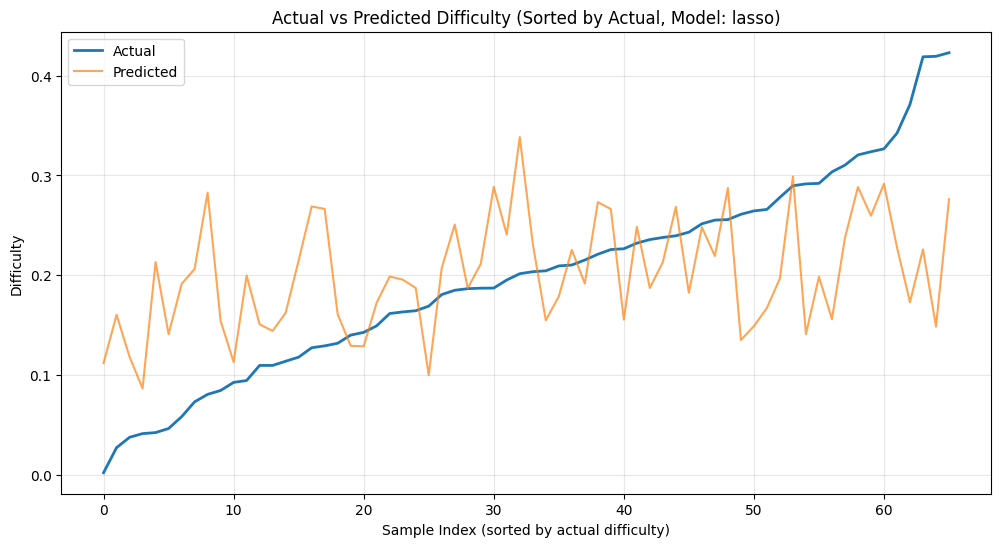

In [7]:
best_model_name = cv_metrics.iloc[0]["model"]
best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

plot_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
}).sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(plot_df["Actual"].values, label="Actual", linewidth=2)
plt.plot(plot_df["Predicted"].values, label="Predicted", alpha=0.7)
plt.title(f"Actual vs Predicted Difficulty (Sorted by Actual, Model: {best_model_name})")
plt.xlabel("Sample Index (sorted by actual difficulty)")
plt.ylabel("Difficulty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Важность признаков

In [8]:
importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error"
)
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": importance.importances_mean
}).sort_values("importance_mean", ascending=False)
feature_importance.head(20)

,feature,importance_mean
24,desc_cyrillic_ratio,3.087691e-03
21,desc_vowel_ratio,8.584270e-04
16,desc_avg_word_len,7.515732e-04
20,desc_unique_chars,6.327770e-04
22,desc_rare_ratio,6.135589e-04
0,ans_len_chars,0.000000e+00
11,ans_latin_ratio,0.000000e+00
15,desc_len_words,0.000000e+00
1,ans_len_words,0.000000e+00
13,ans_has_digits,0.000000e+00
